<a href="https://colab.research.google.com/github/vasilevsavelij135-spec/python-ai-Vasilev-Savelii/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

# Анализ и визуализация данных

В этом ноутбуке я работаю с датасетом `countries_economy_population_area.csv`.

Датасет содержит данные из Wikidata о странах мира: континент, столица, население, площадь, ВВП, рассчитанный ВВП на душу населения и валюту.

Цель анализа — сравнить страны по экономическим, демографическим и территориальным показателям, а также посмотреть различия между континентами.

In [ ]:
# подключаем библиотеки для работы с таблицами и графиками
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# настраиваем внешний вид графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# подключаем библиотеки для работы с таблицами и графиками
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# настраиваем внешний вид графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# указываем raw-ссылку на csv-файл из github
url = "https://raw.githubusercontent.com/vasilevsavelij135-spec/python-ai-Vasilev-Savelii/main/data/countries_economy_population_area.csv"

# читаем данные в dataframe
df = pd.read_csv(url)

# смотрим размер таблицы
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

# показываем первые строки
display(df.head())

Количество строк: 200
Количество столбцов: 9


,country,countryLabel,continentLabel,capitalLabel,population,area,gdp,gdpPerCapitaCalculated,currencyLabel
0,http://www.wikidata.org/entity/Q30,США,Северная Америка,Вашингтон,340110988,9826675.00,28750956130000,84534.040782,доллар США
1,http://www.wikidata.org/entity/Q148,Китай,Азия,Пекин,1404890000,9596961.00,17963170521080,12786.175801,китайский юань
2,http://www.wikidata.org/entity/Q17,Япония,Азия,Токио,123802000,377972.28,5005536736792,40431.792191,японская иена
3,http://www.wikidata.org/entity/Q183,Германия,Европа,Берлин,83577140,357587.77,4121200000000,49310.134326,евро
4,http://www.wikidata.org/entity/Q668,Индия,Азия,Нью-Дели,1326093247,3287263.00,3385089881935,2552.678622,индийская рупия


In [ ]:
# переименовываем столбцы в короткие и понятные имена
df = df.rename(columns={
    "country": "URL",
    "countryLabel": "country",
    "continentLabel": "continent",
    "capitalLabel": "capital",
    "population": "population",
    "area": "area_km2",
    "gdp": "gdp",
    "gdpPerCapitaCalculated": "gdp_per_capita",
    "currencyLabel": "currency"
})

# список числовых столбцов
numeric_columns = ["population", "area_km2", "gdp", "gdp_per_capita"]

# преобразуем числовые столбцы к числовому типу
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# проверяем результат
display(df.head())
df.info()

,URL,country,continent,capital,population,area_km2,gdp,gdp_per_capita,currency
0,http://www.wikidata.org/entity/Q30,США,Северная Америка,Вашингтон,340110988,9826675.00,28750956130000,84534.040782,доллар США
1,http://www.wikidata.org/entity/Q148,Китай,Азия,Пекин,1404890000,9596961.00,17963170521080,12786.175801,китайский юань
2,http://www.wikidata.org/entity/Q17,Япония,Азия,Токио,123802000,377972.28,5005536736792,40431.792191,японская иена
3,http://www.wikidata.org/entity/Q183,Германия,Европа,Берлин,83577140,357587.77,4121200000000,49310.134326,евро
4,http://www.wikidata.org/entity/Q668,Индия,Азия,Нью-Дели,1326093247,3287263.00,3385089881935,2552.678622,индийская рупия


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   URL             200 non-null    object 
 1   country         200 non-null    object 
 2   continent       200 non-null    object 
 3   capital         200 non-null    object 
 4   population      200 non-null    int64  
 5   area_km2        200 non-null    float64
 6   gdp             200 non-null    int64  
 7   gdp_per_capita  200 non-null    float64
 8   currency        200 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 14.2+ KB


In [ ]:
# This cell was causing duplicate column names. It has been emptied.
# The column renaming is handled correctly in cell E7PP3n1NDhC2.

In [ ]:
# считаем пропуски по каждому столбцу
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["column", "missing_count"]

# добавляем процент пропусков
missing_values["missing_percent"] = missing_values["missing_count"] / len(df) * 100

display(missing_values)

,column,missing_count,missing_percent
0,URL,0,0.0
1,country,0,0.0
2,continent,0,0.0
3,capital,0,0.0
4,population,0,0.0
5,area_km2,0,0.0
6,gdp,0,0.0
7,gdp_per_capita,0,0.0
8,currency,0,0.0


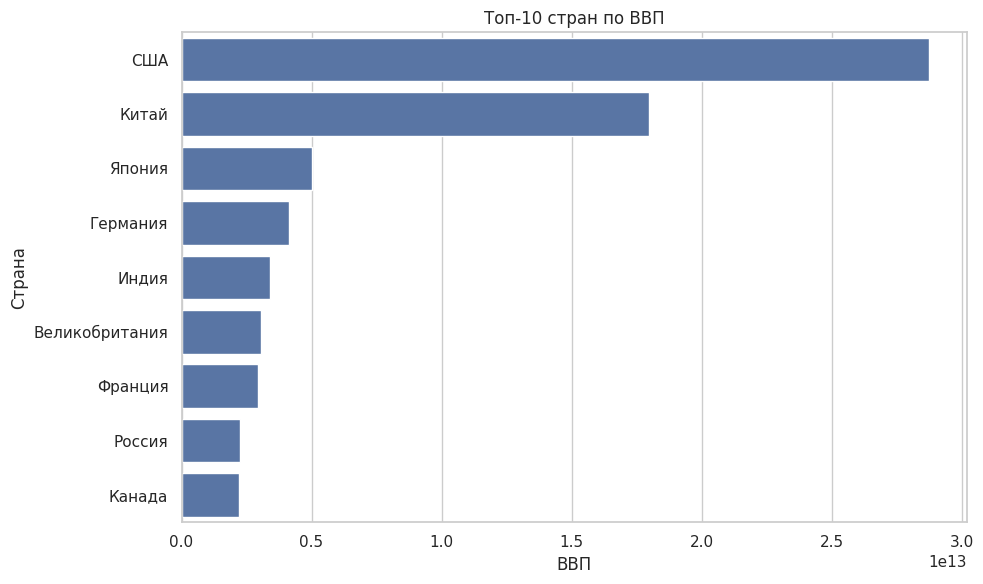

In [ ]:
# выбираем 10 стран с самым большим ввп
top_gdp = df.sort_values("gdp", ascending=False).head(10)

# строим горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(data=top_gdp, x="gdp", y="country")

plt.title("Топ-10 стран по ВВП")
plt.xlabel("ВВП")
plt.ylabel("Страна")

plt.tight_layout()
plt.show()

**Вывод по графику 1:**  
На графике видно, что самый большой общий ВВП имеют крупнейшие экономики мира. В лидерах находятся США и Китай. Это показывает, что общий ВВП отражает масштаб экономики страны, но не обязательно уровень жизни каждого жителя.

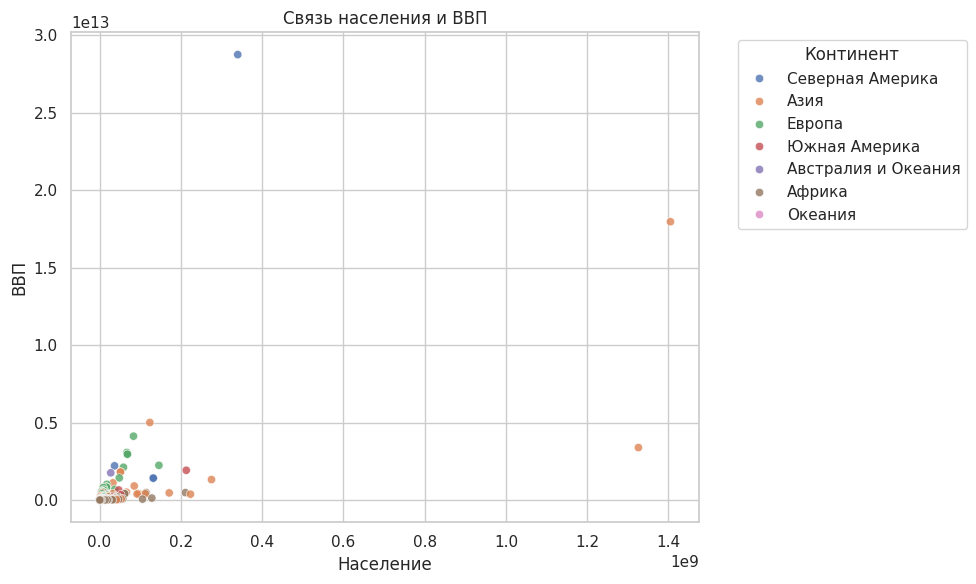

In [ ]:
# строим диаграмму рассеяния для населения и ввп
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="population", y="gdp", hue="continent", alpha=0.8)

plt.title("Связь населения и ВВП")
plt.xlabel("Население")
plt.ylabel("ВВП")

plt.legend(title="Континент", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Вывод по графику 2:**  
На графике видно, что большое население может быть связано с высоким ВВП, но эта связь не является абсолютной. Некоторые страны с относительно меньшим населением имеют высокий ВВП, а некоторые очень населённые страны имеют более низкий ВВП на фоне лидеров.

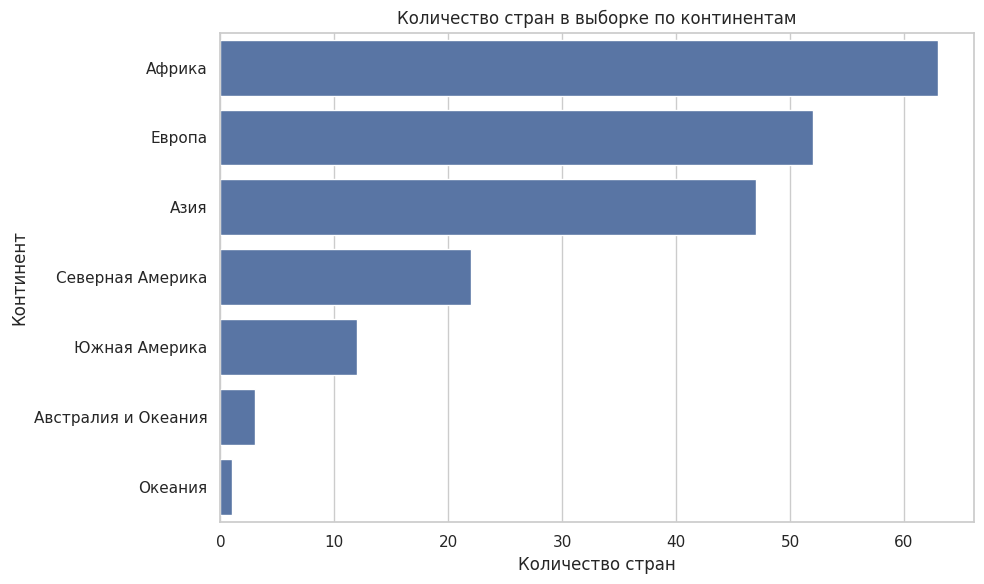

In [ ]:
# считаем количество стран по континентам
continent_counts = df["continent"].value_counts().reset_index()
continent_counts.columns = ["continent", "country_count"]

# строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(data=continent_counts, x="country_count", y="continent")

plt.title("Количество стран в выборке по континентам")
plt.xlabel("Количество стран")
plt.ylabel("Континент")

plt.tight_layout()
plt.show()

**Вывод по графику 3:**  
График показывает, как страны в датасете распределены по континентам. Это важно учитывать при анализе: если один континент представлен большим числом стран, он может сильнее влиять на общую статистику.

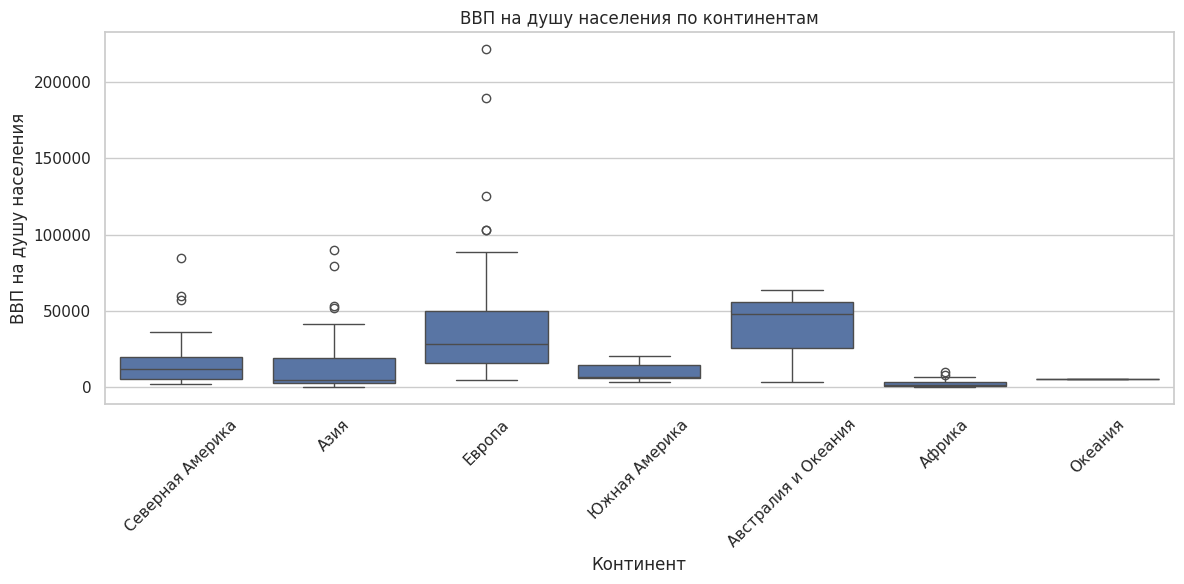

In [ ]:
# строим boxplot для сравнения ввп на душу населения по континентам
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="continent", y="gdp_per_capita")

plt.title("ВВП на душу населения по континентам")
plt.xlabel("Континент")
plt.ylabel("ВВП на душу населения")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод по графику 4:**  
Boxplot показывает, что ВВП на душу населения заметно различается между континентами. Этот показатель лучше подходит для сравнения уровня экономического развития, чем общий ВВП, потому что учитывает численность населения.

In [ ]:
# добавляем новые показатели для анализа
df["population_density"] = df["population"] / df["area_km2"]
df["gdp_trillion"] = df["gdp"] / 1_000_000_000_000
df["gdp_per_capita_thousand"] = df["gdp_per_capita"] / 1000

# проверяем новые столбцы
display(df[["country", "continent", "population_density", "gdp_trillion", "gdp_per_capita_thousand"]].head())

,country,continent,population_density,gdp_trillion,gdp_per_capita_thousand
0,США,Северная Америка,34.610994,28.750956,84.534041
1,Китай,Азия,146.389050,17.963171,12.786176
2,Япония,Азия,327.542538,5.005537,40.431792
3,Германия,Европа,233.724828,4.121200,49.310134
4,Индия,Азия,403.403454,3.385090,2.552679


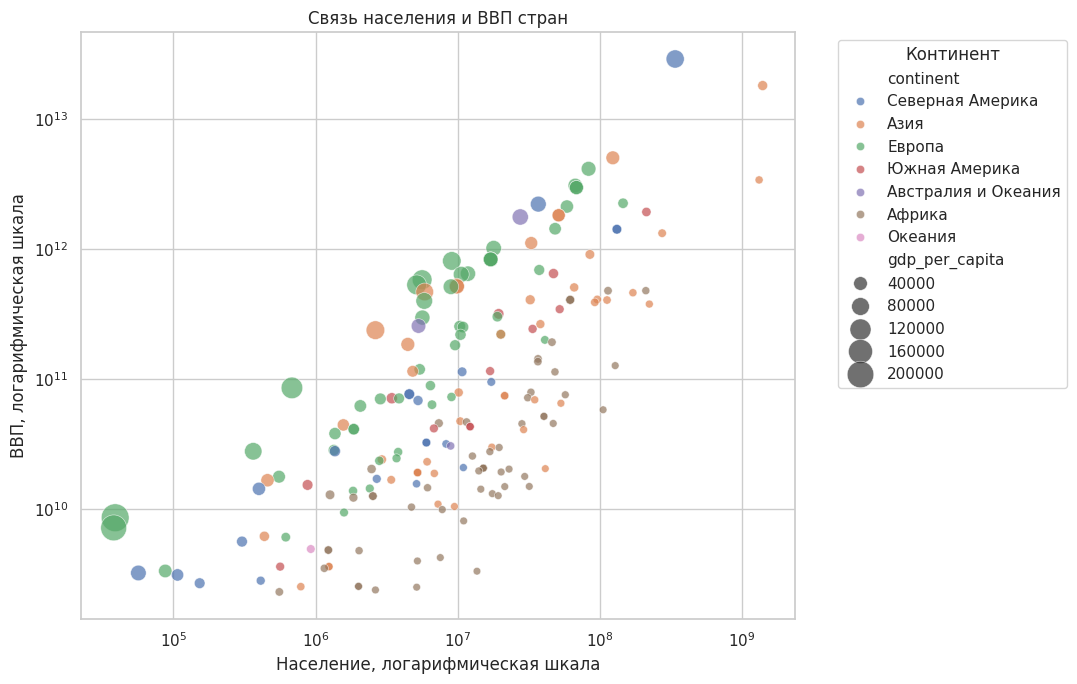

In [ ]:
# строим график связи населения и ввп в логарифмической шкале
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="population",
    y="gdp",
    hue="continent",
    size="gdp_per_capita",
    sizes=(30, 400),
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Связь населения и ВВП стран")
plt.xlabel("Население, логарифмическая шкала")
plt.ylabel("ВВП, логарифмическая шкала")
plt.legend(title="Континент", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Вывод:**  
Логарифмическая шкала позволяет сравнивать как малые, так и крупные страны на одном графике. Видно, что большое население часто связано с большим ВВП, но это не абсолютное правило. Размер точки показывает ВВП на душу населения, поэтому можно увидеть страны, где общий ВВП не самый большой, но экономический показатель на человека высокий.

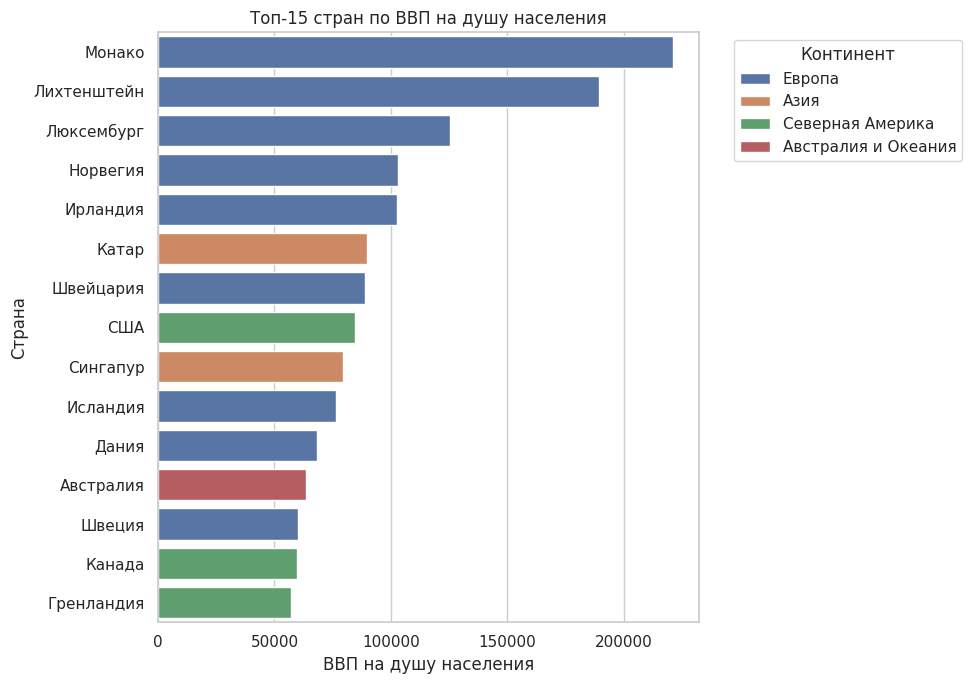

In [ ]:
# выбираем 15 стран с самым большим ввп на душу населения
top_gdp_per_capita = df.sort_values("gdp_per_capita", ascending=False).head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_gdp_per_capita,
    x="gdp_per_capita",
    y="country",
    hue="continent",
    dodge=False
)

plt.title("Топ-15 стран по ВВП на душу населения")
plt.xlabel("ВВП на душу населения")
plt.ylabel("Страна")
plt.legend(title="Континент", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Вывод:**  
График показывает, что лидеры по ВВП на душу населения отличаются от лидеров по общему ВВП. Небольшие страны могут иметь очень высокий показатель на одного жителя, даже если их общий ВВП меньше, чем у крупных экономик.

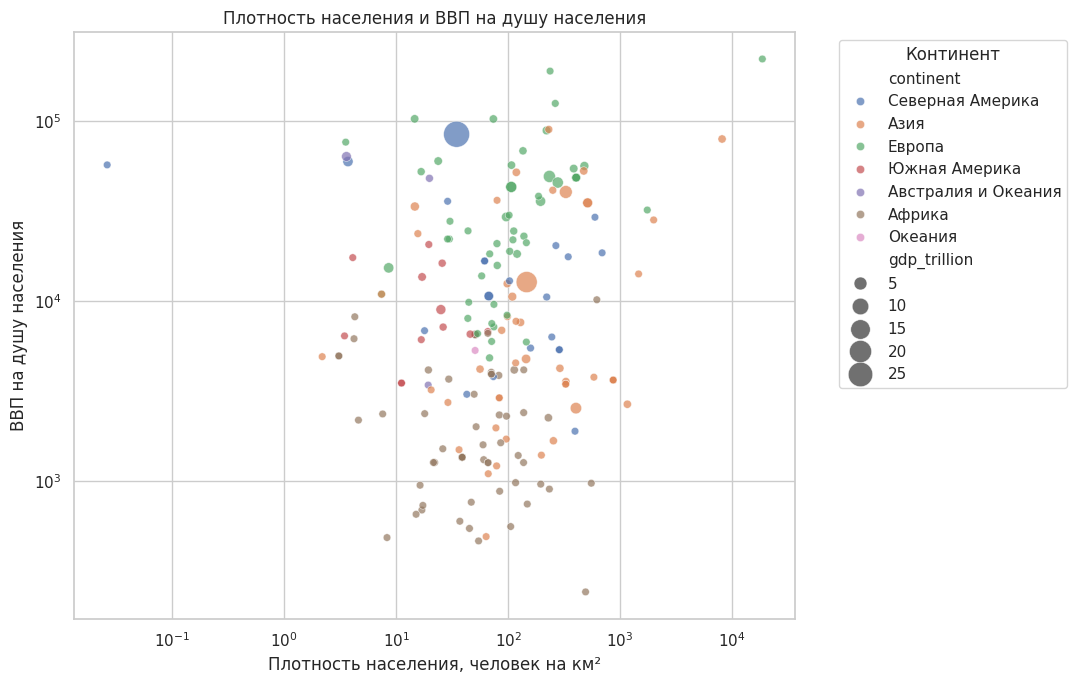

In [ ]:
# убираем слишком маленькие и нулевые значения для корректной логарифмической шкалы
density_data = df[
    (df["population_density"] > 0) &
    (df["gdp_per_capita"] > 0)
]

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=density_data,
    x="population_density",
    y="gdp_per_capita",
    hue="continent",
    size="gdp_trillion",
    sizes=(30, 350),
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Плотность населения и ВВП на душу населения")
plt.xlabel("Плотность населения, человек на км²")
plt.ylabel("ВВП на душу населения")
plt.legend(title="Континент", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Вывод:**  
На графике видно, что высокая плотность населения сама по себе не гарантирует высокий ВВП на душу населения. Есть страны с высокой плотностью и высоким доходом, но есть и страны с высокой плотностью и более низкими экономическими показателями. Это показывает, что на уровень экономики влияют не только население и территория, но и другие факторы.

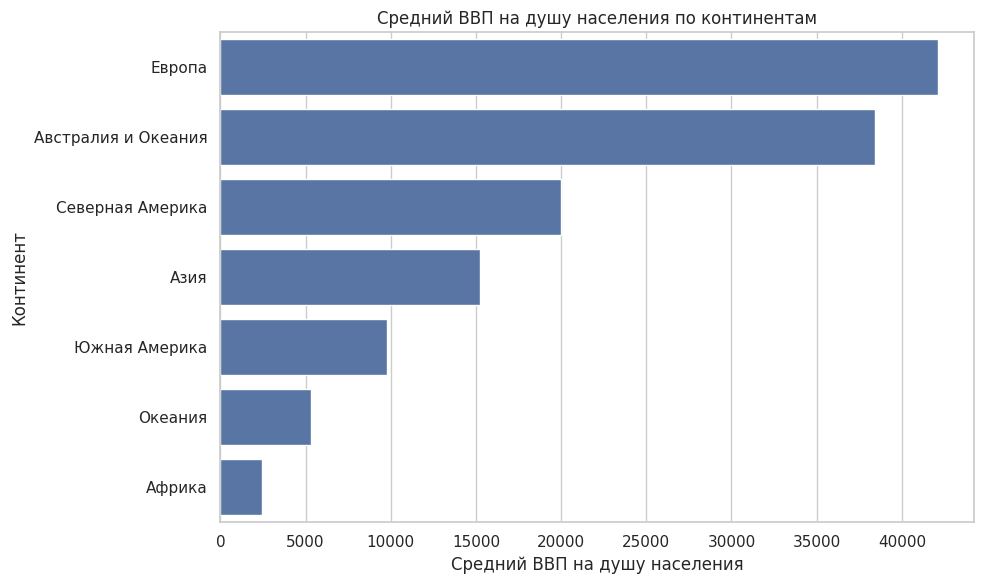

In [ ]:
# считаем средний ввп на душу населения по континентам
continent_gdp_pc = (
    df.groupby("continent", as_index=False)["gdp_per_capita"]
    .mean()
    .sort_values("gdp_per_capita", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=continent_gdp_pc,
    x="gdp_per_capita",
    y="continent"
)

plt.title("Средний ВВП на душу населения по континентам")
plt.xlabel("Средний ВВП на душу населения")
plt.ylabel("Континент")

plt.tight_layout()
plt.show()

**Вывод:**  
График показывает различия между континентами по среднему ВВП на душу населения. Такой показатель удобен для сравнения регионов, потому что учитывает численность населения и позволяет сравнивать не только крупные экономики, но и уровень экономического развития.

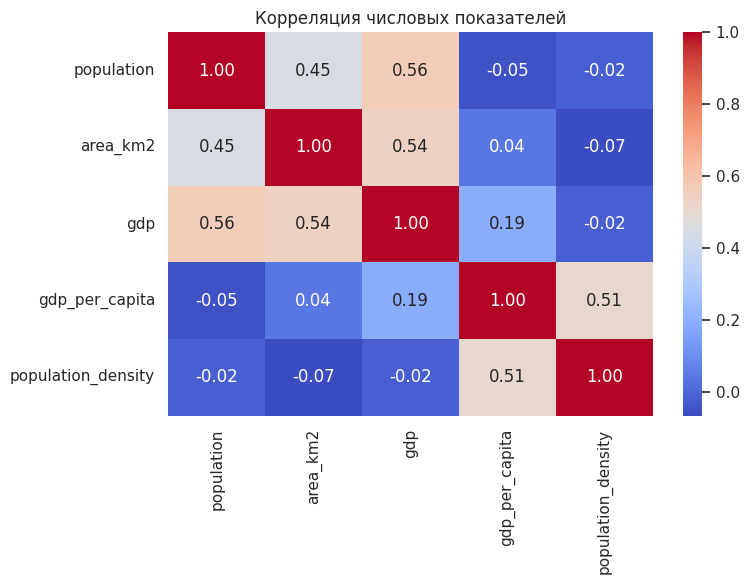

In [ ]:
# выбираем числовые столбцы для корреляции
correlation_columns = [
    "population",
    "area_km2",
    "gdp",
    "gdp_per_capita",
    "population_density"
]

# считаем корреляцию
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Корреляция числовых показателей")

plt.tight_layout()
plt.show()

**Вывод:**  
Тепловая карта показывает, какие числовые показатели сильнее связаны друг с другом. Например, можно проверить, насколько общий ВВП связан с населением, площадью или ВВП на душу населения. Это помогает перейти от простого описания данных к поиску закономерностей.

## Общий вывод

В этом проекте был проведён анализ данных о странах мира, полученных из Wikidata. В датасете рассматривались экономические, демографические и территориальные показатели: население, площадь, ВВП, ВВП на душу населения, континент, столица и валюта.

В ходе анализа стало видно, что общий ВВП страны не всегда отражает уровень экономического благополучия населения. Крупные страны, такие как США и Китай, лидируют по общему ВВП, однако при сравнении ВВП на душу населения в лидерах могут оказаться более небольшие страны. Это показывает различие между масштабом экономики и уровнем экономики в пересчёте на одного жителя.

Также анализ показал, что население и площадь страны не объясняют экономические показатели полностью. Большая территория или большое население могут быть связаны с высоким общим ВВП, но не гарантируют высокий ВВП на душу населения. На экономический уровень страны влияют и другие факторы: структура экономики, уровень развития, географическое положение, природные ресурсы и исторические особенности.

Сравнение по континентам показало, что экономические показатели распределены неравномерно. Между континентами заметны различия по ВВП на душу населения, а внутри некоторых континентов наблюдается большой разброс между странами.

Таким образом, датасет подходит для анализа, потому что содержит как числовые, так и категориальные признаки. Он позволяет сравнивать страны между собой, анализировать различия между континентами и изучать связь между экономикой, населением и территорией.